# Análisis de Ventas — Superstore Dataset

**Autor:** Emanuel Sáenz  
**Proyecto:** Portafolio — Análisis de Ventas de una Tienda Minorista  
**Herramientas:** Python (pandas, matplotlib), Google Colab, Power BI (dashboard)  

**Resumen:**  
Breve análisis descriptivo del dataset *Sample - Superstore*. El objetivo es identificar productos, categorías y regiones con baja rentabilidad y proponer recomendaciones de negocio.


## Índice

1. [Introducción y problema de negocio](#introduccion)  
2. [Dataset y carga de datos](#dataset)  
3. [Limpieza de datos](#limpieza)  
4. [Exploratory Data Analysis (EDA) - ligero](#eda)
5. [Evaluación de la rentabilidad por producto](#rentabilidadxproducto )
6. [Evaluación de la rentabilidad por región](#rentabilidadxregión)
6. [Visualizaciones clave](#visualizaciones)  
7. [Tabla resumen y KPIs](#kpis)  
8. [Conclusiones y recomendaciones](#conclusiones)  
9. [Siguientes pasos / mejoras futuras](#siguientes)


## Introducción <a name="introduccion"></a>

**Contexto de negocio:**  
Identificar los productos, regiones y segmentos con bajo rendimiento en ventas y alto costo logístico, para recomendar dónde enfocar estrategias de mejora.

**Objetivo del análisis:**  
- Determinar las categorías que generan mayor volumen de ventas.  
- Evaluar la rentabilidad por producto y región.  
- Identificar productos con alto volumen pero baja rentabilidad.  
- Proponer recomendaciones accionables.

**Alcance:**  
Análisis descriptivo y exploratorio. No se incluyen modelos predictivos en este entregable.


In [16]:
#Configuración predeterminada para las gráficas
import matplotlib.pyplot as plt

# Estilo general
plt.style.use("seaborn-v0_8-whitegrid")

# Configuración de fuente y tamaño
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.titleweight"] = "bold"


## Dataset y carga de datos <a name="dataset"></a>

**Fuente:** Sample - Superstore dataset (Tableau / Kaggle).  
**Archivo utilizado:** `Sample - Superstore.xls` (subido a Colab).

A continuación se muestra la carga inicial y las primeras filas del dataset.


In [17]:
import pandas as pd
# Definición de formato para la visualización de números decimales
pd.set_option('display.float_format', '{:,.2f}'.format)

#Carga del Dataset
df = pd.read_excel("/content/Sample - Superstore.xls")


# Vista preliminar de los datos
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## Limpieza de datos <a name="limpieza"></a>

**Acciones realizadas:**
- Eliminación de columnas irrelevantes (ej. Row ID, Postal Code) para enfocarnos en análisis de negocio.  
- Conversión de la columna `Order Date` a formato fecha.  
- Creación de la métrica `Profit Margin = Profit / Sales`.  
- Revisión rápida de valores nulos y tipos de datos.

*(En la siguiente celda de código verás el script exacto y el resumen de valores faltantes.)*


In [18]:
# Eliminación de espacios en nombres de columnas para evitar errores de referencia
df.columns = df.columns.str.strip()

# Eliminación de columnas irrelevantes para el análisis de negocio
cols_to_drop = ["Row ID", "Postal Code"]
df = df.drop(columns=cols_to_drop, errors="ignore")


# Conversión de la columna de fecha a formato datetime para análisis temporal
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

# Creación de una nueva métrica: margen de ganancia por registro
df["Profit Margin"] = df["Profit"] / df["Sales"]

# Información general del dataset (tipos de datos y valores nulos)
display(df.info())

# Conteo de valores nulos por columna
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Order Date     9994 non-null   datetime64[ns]
 2   Ship Date      9994 non-null   datetime64[ns]
 3   Ship Mode      9994 non-null   object        
 4   Customer ID    9994 non-null   object        
 5   Customer Name  9994 non-null   object        
 6   Segment        9994 non-null   object        
 7   Country        9994 non-null   object        
 8   City           9994 non-null   object        
 9   State          9994 non-null   object        
 10  Region         9994 non-null   object        
 11  Product ID     9994 non-null   object        
 12  Category       9994 non-null   object        
 13  Sub-Category   9994 non-null   object        
 14  Product Name   9994 non-null   object        
 15  Sales          9994 n

None

,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


## Exploratory Data Analysis (EDA) - Ligero <a name="eda"></a>

Objetivo del EDA: entender distribuciones generales, detectar valores extremos y obtener KPIs rápidos que nos ayuden a priorizar preguntas de negocio.

Secciones:
- Resumen estadístico (ventas, profit, profit margin)
- KPI principales (ventas totales, profit total, promedio profit margin)
- Distribuciones por categoría y región (visualizaciones siguientes)

*(A continuación se muestran `df.describe()` y un bloque con los KPIs clave.)*


In [19]:
# Resumen estadístico de las variables numéricas
df.describe()

# ===============================
# Cálculo de KPIs principales
# ===============================

# Cálculo de métricas clave del negocio
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
avg_margin = df["Profit Margin"].mean()

# Creación de un dataframe resumen con los KPIs
summary = pd.DataFrame({
    "KPI": ["Ventas Totales", "Utilidad Total", "Margen Promedio"],
    "Valor": [total_sales, total_profit, avg_margin]
})

# Aplicación de formato para mejorar la legibilidad de los indicadores
summary.style.format({
    "Valor": lambda x: f"{x:,.2%}" if x < 1 else f"{x:,.2f}"
})

,KPI,Valor
0,Ventas Totales,"2,297,200.86"
1,Utilidad Total,"286,397.02"
2,Margen Promedio,12.03%


**A partir del análisis se observa que la compañía generó aproximadamente:**

- $2,297K en **ventas**

- $286K en **utilidad**

- Con un margen promedio de ~12.03%


## Evaluación de la rentabilidad por producto <a name="rentabilidadxproducto"></a>

El objetivo de este análisis es identificar los productos con mayor y menor margen de ganancia, con el fin de reconocer cuáles representan una oportunidad de mejora operativa y cuáles deben considerarse prioritarios para mantener o potenciar.

Secciones:
- Productos con menor margen
- Productos con alto volumen pero baja rentabilidad
- Productos con mayor margen
- Comparación y conclusión

A continuación, se presentan los hallazgos principales derivados del análisis de rentabilidad por producto.

In [20]:
# ===============================
# Análisis de rentabilidad por producto
# ===============================

# Agrupamos los datos por nombre de producto
# y calculamos el total de ventas y utilidad para cada uno
product_profit = (
    df.groupby("Product Name")[["Sales", "Profit"]]
      .sum()
      # Calculamos el margen de ganancia por producto
      # Margen = Utilidad / Ventas
      .assign(Margin=lambda x: x["Profit"] / x["Sales"])
      # Ordenamos los productos de menor a mayor margen
      .sort_values("Margin")
)


# Visualizamos los 5 productos con menor margen de ganancia
product_profit.head(5)


,Sales,Profit,Margin
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.62,-4.47,-2.75
"Bush Westfield Collection Bookcases, Dark Cherry Finish, Fully Assembled",90.88,-190.85,-2.10
Euro Pro Shark Stick Mini Vacuum,170.74,-325.63,-1.91
Okidata B401 Printer,179.99,-251.99,-1.40
Zebra GK420t Direct Thermal/Thermal Transfer Printer,703.71,-938.28,-1.33


“Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac” registró el menor margen de ganancia, con una pérdida aproximada del 2.75%. Además, presenta un nivel de ventas considerablemente bajo, cercano incluso al 1 % de las ventas del siguiente producto menos rentable.

De manera general, el listado de productos con menor margen corresponde a artículos de rotación limitada y bajo impacto comercial, lo que implica costos de almacenamiento y administración que podrían resultar mayores que su beneficio.

En consecuencia, resulta recomendable evaluar la pertinencia de mantener estos productos en inventario o considerar su sustitución por alternativas de mayor rentabilidad.

In [21]:
# ===============================
# Identificación de productos con alto volumen y baja rentabilidad
# ===============================

# Filtramos productos que:
# - Tienen ventas relativamente altas (mayores a 2,000)
# - Pero presentan un margen de ganancia bajo (menor al 10%)
low_margin = product_profit[(product_profit["Sales"] > 2000) & (product_profit["Margin"] < 0.10)]

# Visualizamos los productos que cumplen estas condiciones
low_margin.head()


,Sales,Profit,Margin
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,"11,099.96","-8,879.97",-0.80
Cubify CubeX 3D Printer Triple Head Print,"7,999.98","-3,839.99",-0.48
O'Sullivan 4-Shelf Bookcase in Odessa Pine,"2,740.20",-975.10,-0.36
BPI Conference Tables,"2,241.87",-795.97,-0.36
StarTech.com 10/100 VDSL2 Ethernet Extender Kit,"2,330.65",-785.76,-0.34


Se identificaron productos con un volumen de ventas considerable, pero con márgenes inferiores al 10 %, e incluso con valores negativos. Este tipo de artículos representan una oportunidad relevante de optimización, ya sea mediante ajustes en precios, acuerdos comerciales con proveedores o revisión de costos logísticos.

En una fase posterior, este análisis será profundizado mediante un dashboard en Power BI, que permitirá priorizar los productos según su volumen y rentabilidad, facilitando la toma de decisiones operativas y comerciales.

In [22]:
# ===============================
# Identificación de productos con mayor margen de ganancia
# ===============================

# Seleccionamos los productos con mayor margen de ganancia
# Ordenamos de forma descendente y tomamos el top 3
top_high_margin = (
    product_profit
    .sort_values("Margin", ascending=False)
    .head(3)
)


# Mostramos los productos con mayor rentabilidad
top_high_margin

,Sales,Profit,Margin
Product Name,,,
Southworth Structures Collection,72.80,36.40,0.50
Tops Green Bar Computer Printout Paper,342.58,171.29,0.50
"Adams Telephone Message Book w/Frequently-Called Numbers Space, 400 Messages per Book",223.44,111.72,0.50


En contraste, los productos con mayor margen presentan niveles de ganancia proporcional sustancialmente superiores a la media. Esto sugiere artículos con costos controlados o con un valor percibido más alto por parte del cliente.

Estos productos pueden considerarse dentro de una categoría “estrella”, dado que representan un mayor retorno económico y pueden ser prioritarios para estrategias de promoción, campañas estacionales o ventas cruzadas.

In [23]:
# ===============================
# Presentación visual de resultados
# ===============================
from IPython.display import display

# Mostramos los productos con menor margen aplicando formato numérico
display(product_profit.head(5).style.format("{:.2f}"))

# Mostramos los productos con mayor margen con el mismo formato
display(top_high_margin.style.format("{:.2f}"))


,Sales,Profit,Margin
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.62,-4.47,-2.75
"Bush Westfield Collection Bookcases, Dark Cherry Finish, Fully Assembled",90.88,-190.85,-2.10
Euro Pro Shark Stick Mini Vacuum,170.74,-325.63,-1.91
Okidata B401 Printer,179.99,-251.99,-1.40
Zebra GK420t Direct Thermal/Thermal Transfer Printer,703.71,-938.28,-1.33


,Sales,Profit,Margin
Product Name,,,
Southworth Structures Collection,72.80,36.40,0.50
Tops Green Bar Computer Printout Paper,342.58,171.29,0.50
"Adams Telephone Message Book w/Frequently-Called Numbers Space, 400 Messages per Book",223.44,111.72,0.50


La comparación entre ambas listas evidencia una brecha significativa entre los artículos menos rentables y aquellos que generan el mayor aporte económico. Esta diferenciación resulta clave para la toma de decisiones sobre sustitución, descontinuación o impulso comercial según el impacto en el margen consolidado.

Este contraste podrá visualizarse de forma más clara y dinámica mediante el dashboard en Power BI, donde será posible segmentar por volumen, margen o categoría.

## Evaluación de la rentabilidad por región<a name="rentabilidadxregión"></a>

El objetivo de esta sección es analizar el desempeño de cada región en términos de ventas totales, utilidad y margen. Este análisis permite identificar cuáles zonas aportan mayor rentabilidad al negocio y en cuáles podrían existir costos operativos elevados, problemas logísticos o precios poco competitivos.

A continuación, se presenta una tabla resumen con las métricas clave por región.


In [24]:
# Agrupamos la información por región
# y calculamos el total de ventas y utilidad para cada una
region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      # Calculamos el margen de ganancia por región
      # Margen = Utilidad / Ventas
      .assign(Margin=lambda x: x["Profit"] / x["Sales"])
      # Ordenamos las regiones de menor a mayor margen
      # para identificar primero las menos rentables
      .sort_values("Margin", ascending=True)
)

# Aplicamos formato visual para evitar notación científica
# y facilitar la lectura de métricas financieras
region_summary = region_summary.style.format({
    "Sales": "{:,.2f}",
    "Profit": "{:,.2f}",
    "Margin": "{:.2%}"
})


# Mostramos la tabla formateada
region_summary


,Sales,Profit,Margin
Region,,,
Central,"501,239.89","39,706.36",7.92%
South,"391,721.91","46,749.43",11.93%
East,"678,781.24","91,522.78",13.48%
West,"725,457.82","108,418.45",14.94%


### Interpretación de métricas

Las siguientes métricas permiten comprender el aporte económico de cada región:

- **Sales**: Volumen total de ventas generado.

- **Profit**: Utilidad obtenida después de costos.

- **Margin**: Proporción de ganancias respecto a las ventas (Profit / Sales).

A partir de la tabla anterior se observa que, aunque todas las regiones generan ventas relevantes, Central y South presentan los márgenes más bajos, lo que indica una rentabilidad reducida en comparación con su volumen de ventas.
En particular, la región Central obtiene aproximadamente la mitad del margen que genera West, lo que sugiere mayores costos, descuentos más agresivos o ineficiencia operativa en esta zona.


## Visualizaciones clave <a name="visualizaciones"></a>

Aquí presentamos las visualizaciones que responden a las preguntas de negocio principales:
- Ventas por categoría
- Tendencia mensual de ventas
- Utilidad por región
- Tabla filtrable de productos (más adelante en Power BI)

Cada gráfica va acompañada de una breve interpretación.


In [25]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

In [26]:
# ===============================
# Función para generar colores dinámicos según el valor
# ===============================
def dynamic_colors(values, cmap_name="Blues"):
    """
    Genera una lista de colores donde:
    - Los valores más altos se representan con colores más intensos
    - Los valores más bajos con tonos más claros

    Esto ayuda a reforzar visualmente la magnitud de los datos.
    """
    # Normalizamos los valores entre 0 y 1
    norm = (values - values.min()) / (values.max() - values.min())

    # Evitamos colores excesivamente claros
    # desplazando el rango a [0.2, 1]
    norm = 0.2 + norm * 0.8

    # Obtenemos la paleta de colores
    cmap = cm.get_cmap(cmap_name)

    # Convertimos cada valor normalizado en un color
    return [cmap(v) for v in norm]


/tmp/ipython-input-2589154410.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


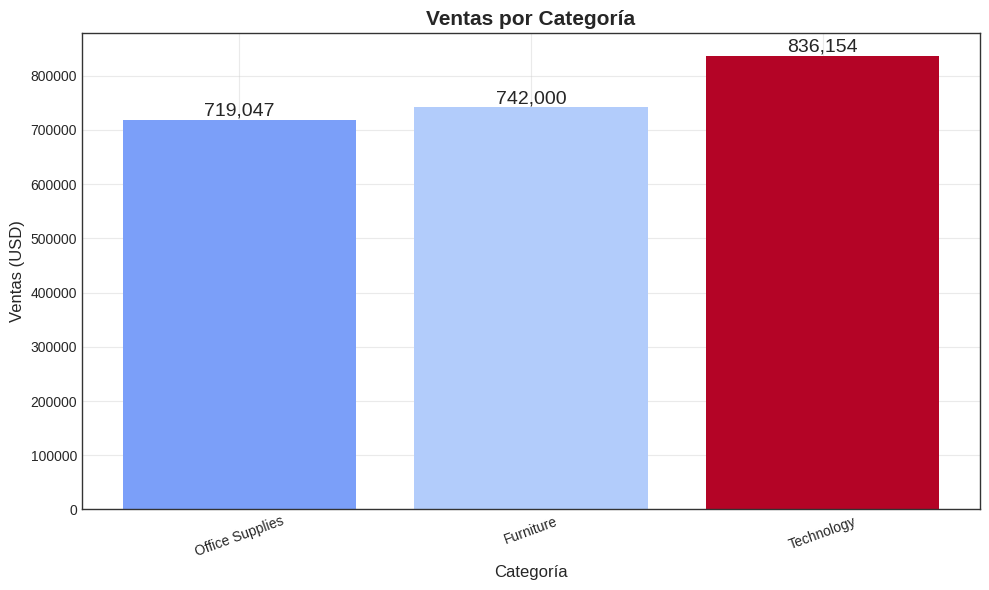

In [27]:
# ===============================
# Gráfica de ventas por categoría
# ===============================

# Calculamos el total de ventas por categoría
category_sales = df.groupby("Category")["Sales"].sum().sort_values()

# Extraemos valores para asignar colores dinámicos
vals = category_sales.values
colors = dynamic_colors(vals, cmap_name="coolwarm")

# Creamos la gráfica
plt.figure()
plt.bar(category_sales.index, category_sales.values, color = colors)


# Etiquetas y título
plt.title("Ventas por Categoría")
plt.ylabel("Ventas (USD)")
plt.xlabel("Categoría")
plt.xticks(rotation=20)


# Etiquetas numéricas sobre cada barra
for i, v in enumerate(category_sales.values):
    plt.text(i, v + (v*0.01), f"{v:,.0f}", ha="center", fontsize=14)


# Ajustes estéticos
plt.tight_layout()
plt.grid(alpha=0.4)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

# Mostrar gráfica
plt.show()


En la gráfica se observa que Technology es la categoría con mayor volumen de ventas, seguida por Furniture, superando a Office Supplies por más de 100,000 USD.
Esto sugiere que Technology es actualmente el principal impulsor de ingresos, mientras que Office Supplies presenta un menor desempeño relativo y podría requerir una revisión de su estrategia comercial.

/tmp/ipython-input-2745967840.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()
/tmp/ipython-input-2745967840.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.plot(monthly_sales.index, monthly_sales.values, linewidth=2, color=cm.get_cmap("coolwarm")(0.6))


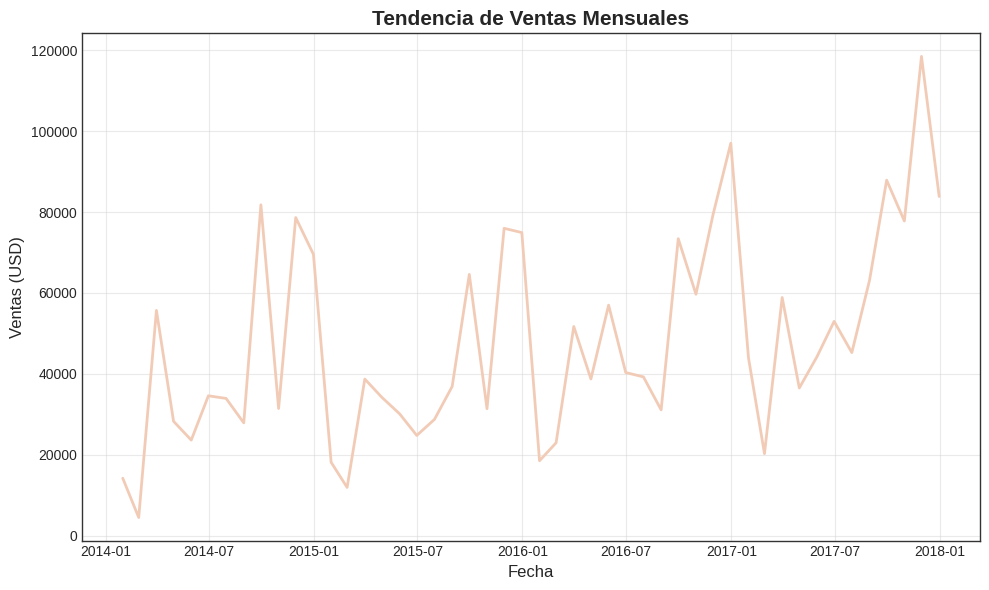

In [28]:
# ===============================
# Tendencia de ventas mensuales
# ===============================

# Aseguramos que la fecha esté en formato datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Agrupamos ventas por mes
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()


# Creamos la gráfica de línea
plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values, linewidth=2, color=cm.get_cmap("coolwarm")(0.6))

# Etiquetas y título
plt.title("Tendencia de Ventas Mensuales")
plt.ylabel("Ventas (USD)")
plt.xlabel("Fecha")


# Ajustes estéticos
plt.grid(alpha=0.4)
plt.tight_layout()
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"


# Mostrar gráfica
plt.show()


Las ventas muestran una tendencia general ascendente a lo largo del período analizado, aunque con variaciones significativas entre meses.
Se observan caídas marcadas en fechas cercanas a inicios de año, donde las ventas se aproximan al mínimo histórico.
Este comportamiento podría estar relacionado con factores estacionales, como la denominada “cuesta de enero”, aunque la magnitud de la caída sugiere la necesidad de analizar posibles impactos en la retención de clientes o en la estrategia comercial.

/tmp/ipython-input-2589154410.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


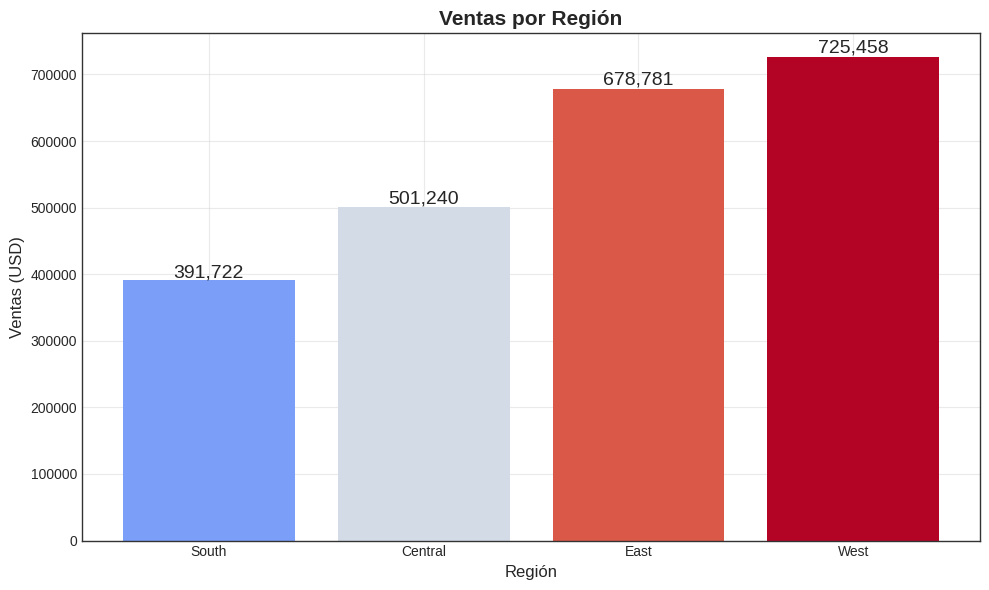

In [29]:
# ===============================
# Gráfica de ventas por región
# ===============================

# Calculamos ventas totales por región
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

# Asignamos colores dinámicos
vals = region_sales.values
colors = dynamic_colors(vals, cmap_name="coolwarm")

# Creamos la gráfica
plt.figure()
plt.bar(region_sales.index, region_sales.values, color=colors)

# Etiquetas y título
plt.title("Ventas por Región")
plt.ylabel("Ventas (USD)")
plt.xlabel("Región")

# Etiquetas numéricas sobre cada barra
for i, v in enumerate(region_sales.values):
    plt.text(i, v + (v*0.01), f"{v:,.0f}", ha="center", fontsize=14)

# Ajustes estéticos
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.tight_layout()
plt.grid(alpha=0.4)

# Mostrar gráfica
plt.show()



La región West presenta el mejor desempeño en términos de rentabilidad, mientras que Central y South muestran resultados significativamente menores.
Esto podría estar asociado a márgenes más bajos o a mayores costos operativos y logísticos en dichas regiones.

## Tabla resumen y KPIs <a name="kpis"></a>

In [30]:
# Calculamos métricas agregadas por categoría
summary = df.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Profit Margin": "mean"
}).reset_index()

# Renombramos columnas para mayor claridad
summary.columns = ["Category", "Sales", "Profit", "Avg Profit Margin"]

# Creamos una fila de totales generales
total_row = pd.DataFrame({
    "Category": ["TOTAL"],
    "Sales": [summary["Sales"].sum()],
    "Profit": [summary["Profit"].sum()],
    "Avg Profit Margin": [summary["Avg Profit Margin"].mean()]
})

# Unimos la fila de totales con la tabla original
summary_with_total = pd.concat([summary, total_row], ignore_index=True)

# Aplicamos formato final para presentación
summary_with_total = summary_with_total.style.format({
    "Sales": "{:,.2f}",
    "Profit": "{:,.2f}",
    "Avg Profit Margin": "{:.2%}"
})

summary_with_total


,Category,Sales,Profit,Avg Profit Margin
0,Furniture,"741,999.80","18,451.27",3.88%
1,Office Supplies,"719,047.03","122,490.80",13.80%
2,Technology,"836,154.03","145,454.95",15.61%
3,TOTAL,"2,297,200.86","286,397.02",11.10%



**KPIs principales**  
- **Ventas totales:** $2,296,200.86  

- **Utilidad total:** $ 286,397.02
- **Margen promedio:** 11.10%  


## Conclusiones y recomendaciones <a name="conclusiones"></a>

El análisis del comportamiento de ventas muestra diferencias relevantes entre categorías y regiones, así como variaciones estacionales que pueden señalar
oportunidades de mejora estratégica.

**Conclusiones clave:**  
1. La categoría con mayores ventas es Technology, seguida de Furniture, mientras que Office Supplies presenta el volumen más bajo. Aunque existe una diferencia de aproximadamente $100,000 USD entre categorías, el desempeño general se mantiene relativamente equilibrado.
Esto indica una cartera de productos diversificada, donde ninguna línea depende excesivamente de otra.

2. Durante el período analizado, las ventas muestran una tendencia general ascendente a lo largo del tiempo, aunque con variaciones mensuales notables.

Se identifican caídas pronunciadas en fechas cercanas al inicio del año, donde las ventas se aproximan al mínimo histórico. Este comportamiento es consistente con factores estacionales como la denominada “cuesta de enero”, periodo en el que el consumo tiende a disminuir.

No obstante, la magnitud de estas caídas sugiere la conveniencia de profundizar en análisis complementarios, como la retención de clientes, cambios en patrones de consumo o ajustes en la estrategia comercial posterior a las temporadas altas.

3. Regionalmente, se identifica que West es la zona más rentable, mientras que Central y South muestran retornos significativamente menores. Esto puede estar asociado a:

- Márgenes reducidos

- Costos logísticos elevados

- Bajos volúmenes de venta por cliente.

La composición de costos por región debería reevaluarse, especialmente en zonas que reportan contribución marginal..  

**Recomendaciones:**  
- Priorizar la categoría de Technology, reforzando campañas de retención y ventas cruzadas.

- Reevaluar los costos logísticos y políticas comerciales en Central y South, con el fin de recuperar margen operativo.

- Analizar la actividad competitiva en temporada de inicio del año para identificar factores de pérdida de clientes.

- Revisar estrategias de precios y descuentos asociadas a volumen.

*(Siguientes pasos propuestos: EDA avanzado, análisis de profit por producto, y creación de un dashboard interactivo en Power BI.)*


## Siguientes pasos / mejoras futuras <a name="siguientes"></a>

- Añadir EDA más profundo: boxplots por categoría, detección de outliers, matriz de correlación.  
- Construir un dashboard interactivo en Power BI con filtros por región, categoría y producto.  
- Evaluar modelos simples de forecasting para ventas mensuales.  
- Mapear códigos postales en caso de requerir análisis geoespacial.
